In [107]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import sys

In [108]:
# Import data
data = pd.read_excel('FactorData.xlsx',index_col = "Dates")
data.index = pd.to_datetime(data.index, format = '%Y%m')
data.tail()

,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
Dates,,,,,,,,,
2025-08-01,0.0184,0.0482,0.0446,-0.0072,0.0196,-0.0360,-0.022993,0.015925,0.0168
2025-09-01,0.0339,-0.0224,-0.0094,-0.0221,-0.0229,0.0463,0.003199,-0.017724,-0.0199
2025-10-01,0.0196,-0.0161,-0.0280,-0.0577,-0.0405,0.0033,-0.028677,-0.035337,-0.0438
2025-11-01,-0.0013,0.0163,0.0357,0.0171,0.0062,-0.0179,0.002650,0.007241,0.0420
2025-12-01,-0.0036,-0.0017,0.0236,0.0044,0.0040,-0.0233,-0.002974,0.005061,0.0062


## 1.1 We now choose the weights on the nine factors without constraining the weight on the market to equal one.

In [109]:
def mv_pp_unc(mu, Sigma):
    Sigmainv = np.linalg.inv(Sigma)
    nominator = Sigmainv @ mu
    w = nominator/sum(nominator)
    return w

In [110]:
mu = data.mean()
Sigma = data.cov()

In [111]:
w_mv_pp_unc = mv_pp_unc(mu, Sigma)
w_mv_pp_unc = pd.Series(w_mv_pp_unc, index=data.columns)
w_mv_pp_unc_df = pd.DataFrame({"w_mv_pp_unc": w_mv_pp_unc})
w_mv_pp_unc_df

,w_mv_pp_unc
Market,0.152163
SMB,0.118346
HML,0.020373
RMW,-0.013776
CMA,-0.109434
UMD,0.025905
ROE,0.277717
IA,0.421920
BAB,0.106785


## 1.2 we constrain the weight on the market factor to equal 1, while all the other weights are unconstrained

In [112]:
def mv_pp_con(n, mu, Sigma):
    A = np.ones((n))
    b = 1
    lb = np.append(1, np.repeat(-9999, n-1))
    ub = np.append(1, np.repeat(9999, n-1))
    
    objective = lambda x: -(mu.T @ x) /(x.T @ Sigma @ x)
    result = minimize(objective, x0 = np.ones(n)/n, bounds = list(zip(lb, ub)))
    return result.x

In [113]:
n = data.shape[1]
mu = np.array(mu)
w_mv_pp_con = mv_pp_con(n, mu, Sigma)

w_mv_pp_con = pd.Series(w_mv_pp_con, index=data.columns)
w_mv_pp_con_df = pd.DataFrame({"w_mv_pp_unc": w_mv_pp_unc,"w_mv_pp_con": w_mv_pp_con})
w_mv_pp_con_df

,w_mv_pp_unc,w_mv_pp_con
Market,0.152163,1.000000
SMB,0.118346,0.100024
HML,0.020373,0.065613
RMW,-0.013776,0.086628
CMA,-0.109434,0.396189
UMD,0.025905,0.151939
ROE,0.277717,0.739266
IA,0.421920,0.802586
BAB,0.106785,0.143181


## 1.3 Find the Sharpe ratio for each of the nine factors and compare it to that of the parametric portfolios.

In [114]:
# Define a function to compute annualized Sharpe ratio
def SharpeRatio(ret, rf = 0):
    Mu = np.mean(ret - rf) * 12
    std = ret.std() * np.sqrt(12)
    return Mu, std, Mu/std

In [115]:
sr_factors = pd.DataFrame(index = data.columns, columns = ['E[R]', 'Volatility', 'SR'])

In [116]:
for k in data.columns:
    ret_k = data[k]
    Mu, std, sharpe = SharpeRatio(ret_k, rf=0)
    sr_factors.loc[k] = [Mu, std, sharpe]

In [117]:
# Compute the Sharpe ratio of the unconstrained parametric portfolio
ret_mv_pp_unc = data @ w_mv_pp_unc
sr_mv_pp_unc = SharpeRatio(ret_mv_pp_unc)
# Compute the Sharpe ratio of the constrained parametric portfolio
ret_mv_pp_con = data @ w_mv_pp_con
sr_mv_pp_con = SharpeRatio(ret_mv_pp_con)

In [118]:
sr_factors.loc[len(sr_factors)] = sr_mv_pp_unc
sr_factors.loc[len(sr_factors)] = sr_mv_pp_con
sr_factors = sr_factors.rename(index={9: 'sr_mv_pp_unc_is'})
sr_factors = sr_factors.rename(index={10: 'sr_mv_pp_con_is'})
sr_factors

,E[R],Volatility,SR
Market,0.071404,0.157458,0.453481
SMB,0.015417,0.107045,0.144021
HML,0.03267,0.106243,0.307502
RMW,0.034192,0.077764,0.439693
CMA,0.031526,0.073073,0.431431
UMD,0.070642,0.147057,0.480372
ROE,0.061229,0.087746,0.697791
IA,0.040039,0.067799,0.590549
BAB,0.09713,0.11439,0.849118
sr_mv_pp_unc_is,0.055534,0.039655,1.400429


## 1.4 Out-of-sample analysis

In [119]:
ret_mv_unc_oos = pd.Series()
ret_mv_con_oos = pd.Series()

In [120]:
for i in data.index[120:]:
    start_month = i - pd.DateOffset(months = 120)
    end_month = i - pd.DateOffset(months = 1)
    df_oos = data.loc[start_month: end_month]
    
    n_i = df_oos.shape[1]
    mu_i = df_oos.mean()
    V_i = df_oos.cov()

    w_mv_unc = mv_pp_unc(mu_i, V_i)
    w_mv_con = mv_pp_con(n_i, mu_i, V_i)

    ret_mv_unc_oos[i] = data.loc[i,:] @ w_mv_unc
    ret_mv_con_oos[i] = data.loc[i,:] @ w_mv_con

    sr_mv_pp_unc_oos =  SharpeRatio(ret_mv_unc_oos)
    sr_mv_pp_con_oos = SharpeRatio(ret_mv_con_oos)
    

In [121]:
sr_factors.loc[len(sr_factors)] = sr_mv_pp_unc_oos
sr_factors.loc[len(sr_factors)] = sr_mv_pp_con_oos
sr_factors = sr_factors.rename(index={11: 'sr_mv_pp_unc_oos'})
sr_factors = sr_factors.rename(index={12: 'sr_mv_pp_con_oos'})
sr_factors

,E[R],Volatility,SR
Market,0.071404,0.157458,0.453481
SMB,0.015417,0.107045,0.144021
HML,0.03267,0.106243,0.307502
RMW,0.034192,0.077764,0.439693
CMA,0.031526,0.073073,0.431431
UMD,0.070642,0.147057,0.480372
ROE,0.061229,0.087746,0.697791
IA,0.040039,0.067799,0.590549
BAB,0.09713,0.11439,0.849118
sr_mv_pp_unc_is,0.055534,0.039655,1.400429


## 2.1 Please use mean-variance optimization to combine original factor with the volatility-managed factor

In [122]:
# We denote `realized variance` for the market return as `RV`
RV = data.rolling(12, closed = 'left').var()

In [123]:
c = 1/(1/RV).mean()

In [124]:
weight_is = c/RV # in-sample volatility multiplier

In [125]:
# Calculate return of the strategy
r_str_is = weight_is*data

In [126]:
# Create an empty dataframe
combine_r_is = pd.DataFrame()

In [127]:
for i in r_str_is.columns:
    combine_df = pd.merge(data[i], r_str_is[i], left_index = True, right_index= True)
    mu_df = combine_df.mean()
    combine_V = combine_df.cov()
    w_df = mv_pp_unc(mu_df, combine_V)
    combine_r_is[i] = combine_df @ w_df

In [128]:
SR_combine_is = combine_r_is.mean()/combine_r_is.std() * np.sqrt(12)

In [129]:
summary = pd.DataFrame({"SR_unconditional":sr_factors.iloc[:-4,-1],"SR_combined_in_sample":SR_combine_is})
summary = summary.T
summary

,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
SR_unconditional,0.453481,0.144021,0.307502,0.439693,0.431431,0.480372,0.697791,0.590549,0.849118
SR_combined_in_sample,0.456296,0.090441,0.338853,0.506293,0.447211,0.686446,0.955009,0.611555,0.9339


## 2.2 out-of-sample analysis

In [130]:
combine_r_oos = pd.DataFrame()

In [131]:
for i in data.index[120:]:
    start_month = i - pd.DateOffset(months = 120)
    end_month = i - pd.DateOffset(months = 1)
    
    Ret_df = data.loc[start_month: end_month]
    r_str_df = r_str_is.loc[start_month: end_month]
    
    for j in Ret_df.columns:
        combine_df = pd.merge(Ret_df[j], r_str_df[j], left_index = True, right_index= True)
        mu_df = combine_df.mean()
        combine_V = combine_df.cov()
        w_df = mv_pp_unc(mu_df, combine_V)
        combine_r_oos.loc[i,j] = w_df[0] * data.loc[i,j] + w_df[1] * r_str_is.loc[i,j]

In [132]:
SR_OOS = combine_r_oos.mean() / combine_r_oos.std()*np.sqrt(12)

In [133]:
# Summary performance of nine factors for the three strategies
summary = pd.DataFrame({"SR_unconditional":sr_factors.iloc[:-4,-1], "SR_combined_in_sample":SR_combine_is, "SR_combined_out_of_sample":SR_OOS})
summary = summary.T
summary

,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
SR_unconditional,0.453481,0.144021,0.307502,0.439693,0.431431,0.480372,0.697791,0.590549,0.849118
SR_combined_in_sample,0.456296,0.090441,0.338853,0.506293,0.447211,0.686446,0.955009,0.611555,0.9339
SR_combined_out_of_sample,-0.135818,-0.070484,-0.003562,0.21386,0.030323,0.580974,0.82894,0.252557,0.707072


## Strategy 1: first calculate vol-timed factors and then use parametric method 

In [134]:
combine_r_oos.head()

,Market,SMB,HML,RMW,CMA,UMD,ROE,IA,BAB
1977-02-01,-0.048514,0.865994,0.003693,-0.002529,-0.001801,0.004229,0.012975,0.001295,0.017776
1977-03-01,-0.030506,0.215329,-0.029359,-0.015023,-0.001137,0.006606,0.004864,-0.001806,0.009750
1977-04-01,0.003516,-0.030495,-0.083461,-0.100736,0.014320,0.061015,0.010456,0.014015,0.007745
1977-05-01,-0.034593,0.155956,-0.003905,0.020323,0.001226,0.027214,0.053626,0.002109,0.007975
1977-06-01,0.112971,0.380951,0.007849,0.204126,-0.015775,0.026002,0.060973,-0.007950,-0.001762


In [135]:
ST1_ret_mv_unc_oos = pd.Series()
ST1_ret_mv_con_oos = pd.Series()

In [136]:
for i in combine_r_oos.index[120:]:
    start_month = i - pd.DateOffset(months = 120)
    end_month = i - pd.DateOffset(months = 1)
    df_oos = combine_r_oos.loc[start_month: end_month]
    
    n_i = df_oos.shape[1]
    mu_i = df_oos.mean()
    V_i = df_oos.cov()

    w_mv_unc = mv_pp_unc(mu_i, V_i)
    w_mv_con = mv_pp_con(n_i, mu_i, V_i)

    ST1_ret_mv_unc_oos[i] = combine_r_oos.loc[i,:] @ w_mv_unc
    ST1_ret_mv_con_oos[i] = combine_r_oos.loc[i,:] @ w_mv_con

    sr_mv_pp_unc_oos_ST1 =  SharpeRatio(ST1_ret_mv_unc_oos)
    sr_mv_pp_con_oos_ST1 = SharpeRatio(ST1_ret_mv_con_oos)

In [137]:
sr_factors.loc[len(sr_factors)] = sr_mv_pp_unc_oos_ST1
sr_factors.loc[len(sr_factors)] = sr_mv_pp_con_oos_ST1
sr_factors = sr_factors.rename(index={13: 'sr_mv_pp_unc_oos_ST1'})
sr_factors = sr_factors.rename(index={14: 'sr_mv_pp_con_oos_ST1'})
sr_factors

,E[R],Volatility,SR
Market,0.071404,0.157458,0.453481
SMB,0.015417,0.107045,0.144021
HML,0.03267,0.106243,0.307502
RMW,0.034192,0.077764,0.439693
CMA,0.031526,0.073073,0.431431
UMD,0.070642,0.147057,0.480372
ROE,0.061229,0.087746,0.697791
IA,0.040039,0.067799,0.590549
BAB,0.09713,0.11439,0.849118
sr_mv_pp_unc_is,0.055534,0.039655,1.400429


## Strategy 2:first calculate vol-timed factors, pick the good factors, and then use parametric method 

In [138]:
combine2 = pd.merge(
    data.drop(columns=["HML", "UMD", "ROE"]),  # Exclude columns
    combine_r_oos[["HML", "UMD", "ROE"]],     # Select specific columns
    left_index=True,
    right_index=True
)

In [139]:
combine2

,Market,SMB,RMW,CMA,IA,BAB,HML,UMD,ROE
1977-02-01,-0.0194,0.0108,-0.0013,-0.0019,0.001210,0.0249,0.003693,0.004229,0.012975
1977-03-01,-0.0137,0.0099,-0.0032,-0.0009,-0.001567,0.0123,-0.029359,0.006606,0.004864
1977-04-01,0.0015,-0.0012,-0.0203,0.0116,0.012277,0.0106,-0.083461,0.061015,0.010456
1977-05-01,-0.0145,0.0118,0.0033,0.0011,0.002061,0.0104,-0.003905,0.027214,0.053626
1977-06-01,0.0471,0.0213,0.0088,-0.0122,-0.007070,-0.0022,0.007849,0.026002,0.060973
...,...,...,...,...,...,...,...,...,...
2025-08-01,0.0184,0.0482,-0.0072,0.0196,0.015925,0.0168,0.025413,-0.035552,-0.026066
2025-09-01,0.0339,-0.0224,-0.0221,-0.0229,-0.017724,-0.0199,-0.003274,0.051528,0.003545
2025-10-01,0.0196,-0.0161,-0.0577,-0.0405,-0.035337,-0.0438,-0.011491,0.002089,-0.032007
2025-11-01,-0.0013,0.0163,0.0171,0.0062,0.007241,0.0420,0.013563,-0.014220,0.002576


In [140]:
ST2_ret_mv_unc_oos = pd.Series()
ST2_ret_mv_con_oos = pd.Series()

In [141]:
for i in combine2.index[120:]:
    start_month = i - pd.DateOffset(months = 120)
    end_month = i - pd.DateOffset(months = 1)
    df_oos = combine2.loc[start_month: end_month]
    
    n_i = df_oos.shape[1]
    mu_i = df_oos.mean()
    V_i = df_oos.cov()

    w_mv_unc = mv_pp_unc(mu_i, V_i)
    w_mv_con = mv_pp_con(n_i, mu_i, V_i)

    ST2_ret_mv_unc_oos[i] = combine2.loc[i,:] @ w_mv_unc
    ST2_ret_mv_con_oos[i] = combine2.loc[i,:] @ w_mv_con

    sr_mv_pp_unc_oos_ST2 =  SharpeRatio(ST2_ret_mv_unc_oos)
    sr_mv_pp_con_oos_ST2 = SharpeRatio(ST2_ret_mv_con_oos)

In [142]:
sr_factors.loc[len(sr_factors)] = sr_mv_pp_unc_oos_ST2
sr_factors.loc[len(sr_factors)] = sr_mv_pp_con_oos_ST2
sr_factors = sr_factors.rename(index={15: 'sr_mv_pp_unc_oos_ST2'})
sr_factors = sr_factors.rename(index={16: 'sr_mv_pp_con_oos_ST2'})
sr_factors

,E[R],Volatility,SR
Market,0.071404,0.157458,0.453481
SMB,0.015417,0.107045,0.144021
HML,0.03267,0.106243,0.307502
RMW,0.034192,0.077764,0.439693
CMA,0.031526,0.073073,0.431431
UMD,0.070642,0.147057,0.480372
ROE,0.061229,0.087746,0.697791
IA,0.040039,0.067799,0.590549
BAB,0.09713,0.11439,0.849118
sr_mv_pp_unc_is,0.055534,0.039655,1.400429


In [143]:
sr_factors.iloc[9:,:]

,E[R],Volatility,SR
sr_mv_pp_unc_is,0.055534,0.039655,1.400429
sr_mv_pp_con_is,0.192581,0.157345,1.223944
sr_mv_pp_unc_oos,0.049236,0.049997,0.984766
sr_mv_pp_con_oos,0.232047,0.168494,1.377179
sr_mv_pp_unc_oos_ST1,-2.187096,13.203282,-0.165648
sr_mv_pp_con_oos_ST1,1.682087,4.707278,0.357338
sr_mv_pp_unc_oos_ST2,0.041971,0.047516,0.883297
sr_mv_pp_con_oos_ST2,0.198216,0.168446,1.176735


## Plot

In [144]:
result = pd.concat([ret_mv_unc_oos, ret_mv_con_oos, ST1_ret_mv_unc_oos, ST1_ret_mv_con_oos, ST2_ret_mv_unc_oos, ST2_ret_mv_con_oos], axis=1)

In [145]:
result.columns = ["ret_mv_unc_oos", "ret_mv_con_oos", "ST1_ret_mv_unc_oos", "ST1_ret_mv_con_oos", "ST2_ret_mv_unc_oos", "ST2_ret_mv_con_oos"]

In [146]:
cum = result.cumsum()

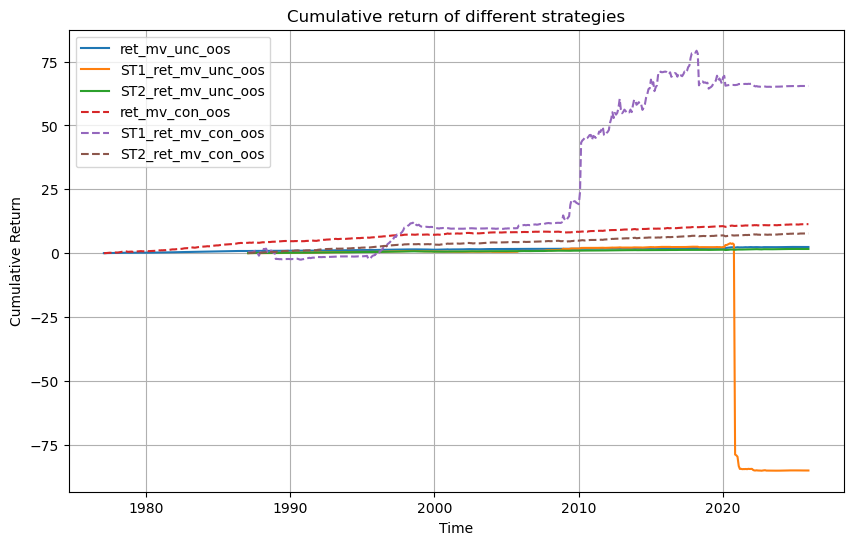

In [147]:
# Plot each column manually
plt.figure(figsize=(10, 6))
for column in cum.columns[[0,2,4]]:
    plt.plot(cum.index, cum[column], label=column)

for column in cum.columns[[1,3,5]]:
    plt.plot(cum.index, cum[column], linestyle = "--", label=column)

# Add labels, title, legend, and grid
plt.title("Cumulative return of different strategies")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

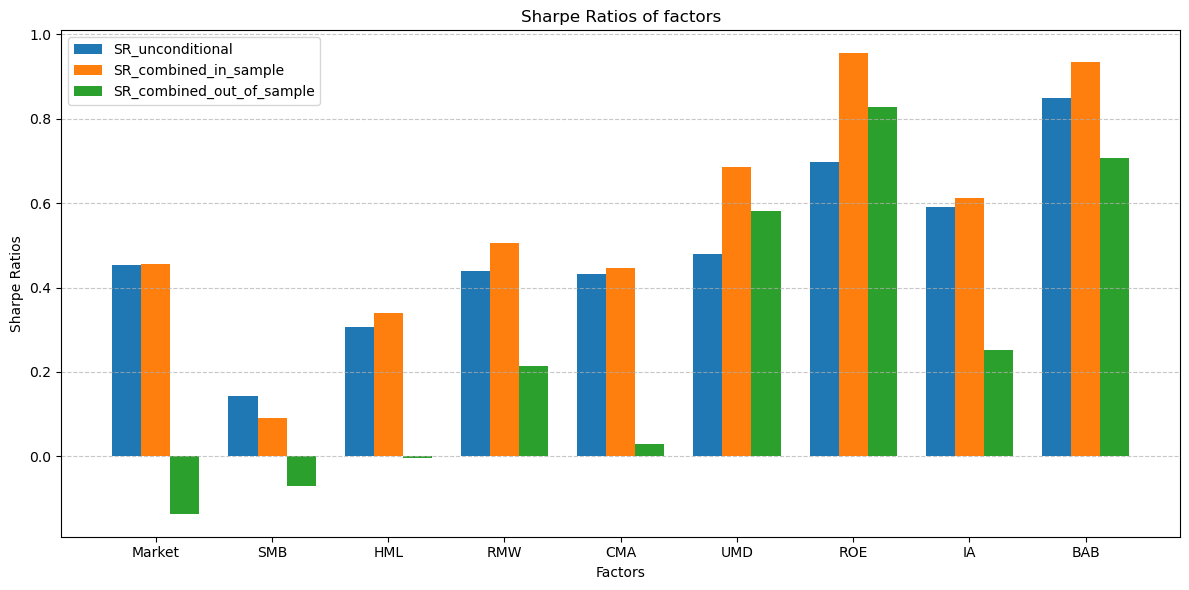

In [105]:
# Assuming 'summary' is your DataFrame
columns = summary.columns  # Column names (A-I)
rows = summary.index       # Row indices
values = summary.values    # Data as a NumPy array

# Number of groups (columns) and bars in each group (rows)
num_columns = len(columns)
num_rows = len(rows)

# Create positions for groups and bars
x = np.arange(num_columns)  # Group positions
bar_width = 0.25  # Width of each bar
offsets = np.linspace(-bar_width, bar_width, num_rows)  # Offsets for each bar

# Create the bar plot
plt.figure(figsize=(12, 6))
for i, row in enumerate(rows):
    plt.bar(
        x + offsets[i],              # Positions for this row's bars
        values[i],                   # Values from the row
        bar_width,                   # Bar width
        label=f"{row}"           # Legend label
    )

# Add labels, title, and legend
plt.xticks(x, columns)  # Set x-ticks to column names
plt.xlabel("Factors")
plt.ylabel("Sharpe Ratios")
plt.title("Sharpe Ratios of factors")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

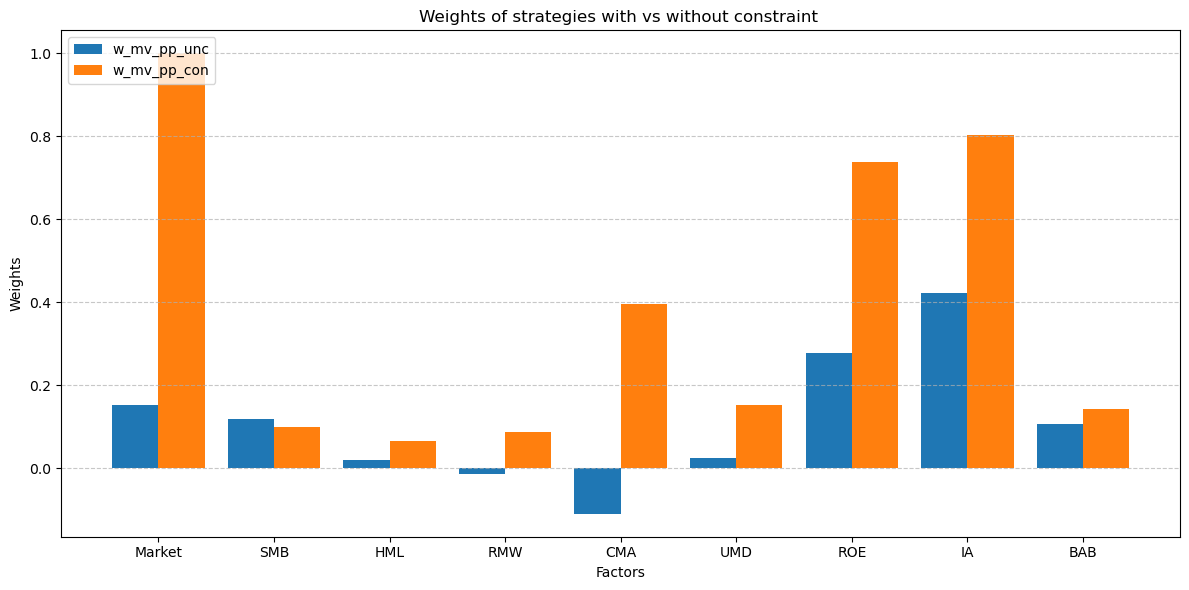

In [106]:

# Assuming 'summary' is your DataFrame
columns = w_mv_pp_con_df.T.columns  # Column names (A-I)
rows = w_mv_pp_con_df.T.index       # Row indices
values = w_mv_pp_con_df.T.values    # Data as a NumPy array

# Number of groups (columns) and bars in each group (rows)
num_columns = len(columns)
num_rows = len(rows)

# Create positions for groups and bars
x = np.arange(num_columns)  # Group positions
bar_width = 0.4  # Width of each bar

# Create the bar plot
plt.figure(figsize=(12, 6))
for i, row in enumerate(rows):
    plt.bar(
        x + (i - 0.5) * bar_width,              # Positions for this row's bars
        values[i],                   # Values from the row
        bar_width,                   # Bar width
        label=f"{row}"           # Legend label
    )

# Add labels, title, and legend
plt.xticks(x, columns)  # Set x-ticks to column names
plt.xlabel("Factors")
plt.ylabel("Weights")
plt.title("Weights of strategies with vs without constraint ")
plt.legend(loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

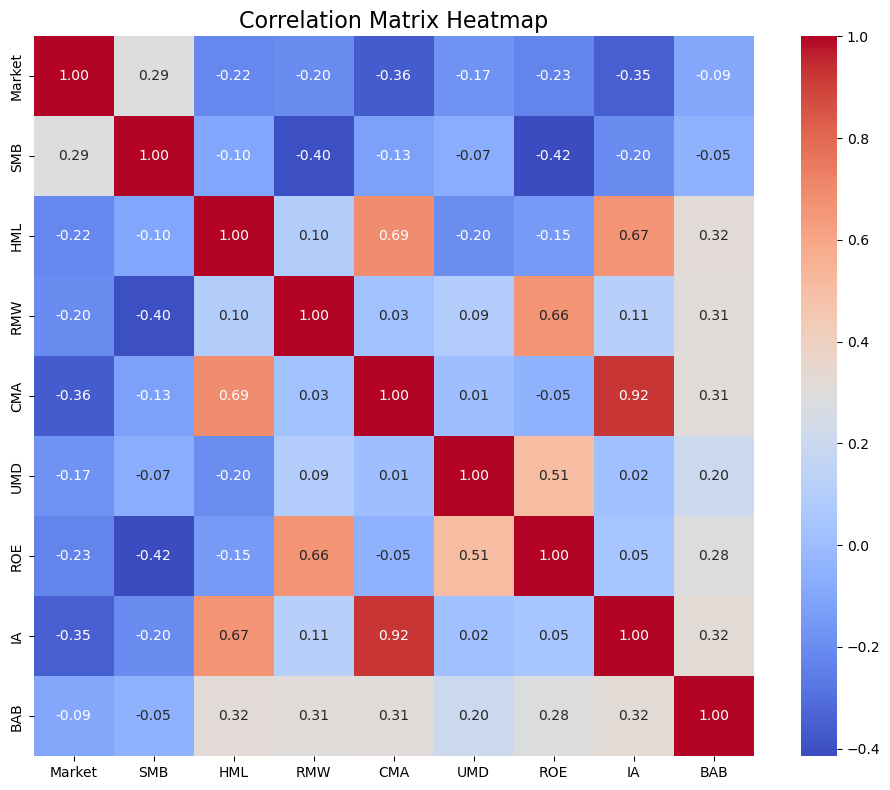

In [45]:
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = data.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,          # Correlation matrix
    annot=True,                  # Annotate cells with correlation coefficients
    fmt=".2f",                   # Format for annotations (2 decimal places)
    cmap="coolwarm",             # Color map
    cbar=True,                   # Include color bar
    square=True                  # Make cells square
)

# Add title
plt.title("Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()
